Pasos:
* 0- Importar paqueterías y leer archivos
* 1- Revisamos si hay nulos y también el tipo de datos que tenemos
* 2- Primeras transformaciones de los datos (modificar fechas y quitar columnas id)
* 3- Analisis del primario de las columnas y serie de tiempo
* 4- Dummies para eliminar datos categoricos y sus respectivos nulos
* 5- Tratamiento de los datos continuos (Aplicamos logaritmo a monto, Escalamos y rellenamos na's)
* 6- PCA 
* 7- Modelado (DB-SCAN y Isolation Forest)
* 8- Correlaciones y Random Forest Regression
* 9- Analisis y agrupado por cuenta
* 10- Conclusiones basadas en estadistica

### 0 -Importacion de paqueterias y lectura de archivo

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import math
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

In [2]:
Ruta_Data = 'C:/Users/jesus/OneDrive/Escritorio/MELI_PRUEBA'
Archivo_Fraude = pd.read_csv(f'{Ruta_Data}/CASO1.csv')

In [3]:
print("# de elementos del DF:",len(Archivo_Fraude))
print("# de columnas del DF:",len(Archivo_Fraude.columns))
Archivo_Fraude.head()

# de elementos del DF: 177106
# de columnas del DF: 20


,CUENTA_ID_HASH,NO_IDENTIFACION_HASH,ENTIDAD_FEDERATIVA,CALLE_HASH,COLONIA_HASH,CODIGO_POSTAL_HASH,EDAD,KYC_PRIMARY_ACTIVITY_CODE,OCUPACION,FECHA_INICIO_RELACION,FLUJO,MOVIMIENTO,CONTRAPARTE_HASH,TRX_ID_HASH,PAY_TOTAL_PAID_AMT,PAY_CREATED_DATETIME,SERVICIO,PAY_OPERATION_TYPE_ID,PAY_PAYMENT_METHOD_TYPE_ID,PAY_PAYMENT_METHOD_ID
0,+jKiq7nnmfQSFTr1hHV/yS94O5LE597jS/nmUh4H7+4=,8wZB9A9a3K0aeywn3MU3o3du7pLVHnIXLEV79tQ4jf4=,Yucatán,RMtzDEIEgKBHe1Ba5or1CPuQ+Wzw7FTGrRaUndQn8To=,PDtVhb9j0B9Et/CKCZu1WBGC0kSHWbwoWOqe3/qmYzI=,hnSJIoqUCos0n6ROAZYYvDPrH3XW5RfVlMHRfuHyTGA=,43.0,AC024002,NaN,2022-06-09 16:04:59,SALIDAS,Pagos,lbnXoX3/7XCbiiYfPOLYJS1iSfTjG7zhJGM9fOjvil8=,/CH9Z6tYG7ueE3zdMpwLmt4tzeEjKMo+NUlHaDZVE6I=,254.40,2024-06-04 18:40:14,PAGO_TARJETA_MP,regular_payment,account_money,account_money
1,gzfo2hWwW3qmd/iOyO+/jC9GbxN+g+SxwkWPjB4Ldes=,Bit2yHqdA1WrQh10kWnB5aauP9EKs/+uKq40pmul9wA=,Estado De México,dtqjzGsFbzrupWH+XKhI1OVfSSMKughz3B/RJs7uaWg=,EMkuPPYCvjk1pzl7nDW8+qljjnlsbbWYR6KbXfohUQk=,5pAMtaagYY8iz2LDo8bgMMn0DNClclN+Da4P32RNUXw=,60.0,AC022001,MERCHANT,2022-06-07 23:55:40,SALIDAS,Pagos,/G5X46K55RGa9sI3IUVW/XhAt4dx64IZBCqpWeZooaI=,EVz4PKk4YTT5Og/D99VmY2iukNRdt6RVBxHussFbp9U=,68.00,2024-08-23 16:49:37,PAGO_DINERO_CUENTA,regular_payment,account_money,account_money
2,WRY8ZDdbAkNFifA5Y5Q8JDzKNV2WJyniiGfM24PXcLc=,xDFBqKTembGx0jj/mPMTZ0RFHQR9fCJ+QDW/BPDmjqQ=,Veracruz,1MKuFRIyxXURq96yfdMOds49XubKVF1m5yUIm7bkQI0=,vvK1e68Sy4LHydKpasYAISNY8JWMoH+bBdhs0jQPXr0=,WFDROyPDT1ZiygAbZroM1YFJrymV9EFh4bDvMQZS744=,64.0,AC003014,NaN,2023-03-24 14:59:59,ENTRADAS,Ingreso por procesamiento de pagos,HDjMX3tDbaKUoxTEezJ/y8z6u2At8t+huqzgFlcq+IU=,UvTDigvvINDW64hGbtsg5DcwXAbqHPk33Y3Omc+Y2rM=,98.80,2024-04-13 11:36:07,POINT,pos_payment,debit_card,debmaster
3,KVQvDUy5QFXNaf72keEdOcBVKfUgwAsp6vYSWI3aoD4=,piQbewAHJC3V6MRYI05qIzGfdxuhfqTw4bFnkCS+fVM=,Durango,nH9ikKf+ObnZf3f/7JTALBcGpnRSqLmhloRV3ohcTo0=,mzeaDP73X7j3QtbqtD+DLm1tmpKFymSQ9OXwkfLOQKo=,yIEmPo4wWWs7Brgbf18TMh3O/3Wts+3dL1+n4bBXIcQ=,33.0,NaN,HOUSEKEEPER,2024-07-18 00:12:18,ENTRADAS,Ingreso por procesamiento de pagos,plIlQ6lp51L52lHuBBRdjra7Lr8p6h/WHvPApmw8qXE=,Ztv1EEjZQtqpbSFRlL5T0hUwoHwZkFCtmSuBflk3x2s=,31.64,2024-12-06 00:57:54,PAGO_DINERO_CUENTA,regular_payment,account_money,account_money
4,fsLBun5mvhVq3xqAZIyao3lLeTHrgoynBYnAdTdPssk=,KJM9ehcAM21dBJ6a9bp9vV7AxLtJTy6+6s6OwwQ/suI=,Querétaro,B2GBq3G4xF8XzjKTV7N/IPLe6+Qw0Jp9yhi2JS1m4j8=,by/Jy0uOK30H1hD7VQ4a9HnxGiIkUjOOEWYD+oTEHUs=,pyaqo3iAEhsV3sqKHn4UZOuwzctRTCnruZ4qXgCMTxc=,28.0,NaN,SELFEMPLOYEDPROFESSIONAL,2023-05-31 16:59:48,ENTRADAS,Money in vía transferencia (Clabe),NaN,YteEQZz+jyEcKIW55eoOZXhf0/c4CZpOh1wFYy+QJmY=,1300.00,2024-11-07 14:10:55,FONDEO_CLABE,account_fund,bank_transfer,clabe


### Revisando el dataset nos damos cuenta que son transacciones y solo 140 cuentas. Por lo que haremos dos enfoques. Uno a nivel general de las transacciones y otro agrupado por cuentas, ademas incluiremos una serie de tiempo

In [4]:
print(Archivo_Fraude.columns)

Index(['CUENTA_ID_HASH', 'NO_IDENTIFACION_HASH', 'ENTIDAD_FEDERATIVA',
       'CALLE_HASH', 'COLONIA_HASH', 'CODIGO_POSTAL_HASH', 'EDAD',
       'KYC_PRIMARY_ACTIVITY_CODE', 'OCUPACION', 'FECHA_INICIO_RELACION',
       'FLUJO', 'MOVIMIENTO', 'CONTRAPARTE_HASH', 'TRX_ID_HASH',
       'PAY_TOTAL_PAID_AMT', 'PAY_CREATED_DATETIME', 'SERVICIO',
       'PAY_OPERATION_TYPE_ID', 'PAY_PAYMENT_METHOD_TYPE_ID',
       'PAY_PAYMENT_METHOD_ID'],
      dtype='object')


### 1 -Revisamos los nulos y observamos que tipo de datos existen en nuestro conjunto:

In [5]:
Archivo_Fraude.isnull().any().any()
# Con este true comprobamos que si hay datos nulos en la base de datos. Habrá que hacerse un analisis para ver porque existen estos nulos

True

In [6]:
Archivo_Fraude.isnull().any().value_counts()
# Contamos con 14 columnas de nulos.

True     14
False     6
Name: count, dtype: int64

In [7]:
Archivo_Fraude.columns[Archivo_Fraude.isnull().any()==True]

Index(['NO_IDENTIFACION_HASH', 'EDAD', 'KYC_PRIMARY_ACTIVITY_CODE',
       'OCUPACION', 'FLUJO', 'MOVIMIENTO', 'CONTRAPARTE_HASH', 'TRX_ID_HASH',
       'PAY_TOTAL_PAID_AMT', 'PAY_CREATED_DATETIME', 'SERVICIO',
       'PAY_OPERATION_TYPE_ID', 'PAY_PAYMENT_METHOD_TYPE_ID',
       'PAY_PAYMENT_METHOD_ID'],
      dtype='object')

In [8]:
Archivo_Fraude.info()
# Hasta abajo podemos ver un resumen de cuantas variables del tipo objeto hay y cuantas del tipo flotante hay

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177106 entries, 0 to 177105
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CUENTA_ID_HASH              177106 non-null  object 
 1   NO_IDENTIFACION_HASH        167085 non-null  object 
 2   ENTIDAD_FEDERATIVA          177106 non-null  object 
 3   CALLE_HASH                  177106 non-null  object 
 4   COLONIA_HASH                177106 non-null  object 
 5   CODIGO_POSTAL_HASH          177106 non-null  object 
 6   EDAD                        167085 non-null  float64
 7   KYC_PRIMARY_ACTIVITY_CODE   54803 non-null   object 
 8   OCUPACION                   123038 non-null  object 
 9   FECHA_INICIO_RELACION       177106 non-null  object 
 10  FLUJO                       177105 non-null  object 
 11  MOVIMIENTO                  177105 non-null  object 
 12  CONTRAPARTE_HASH            163992 non-null  object 
 13  TRX_ID_HASH   

In [9]:
# Creamos listas con los tipos de datos
Columnas_Objetos = Archivo_Fraude.columns[Archivo_Fraude.dtypes=='object']
Columnas_Continuos = Archivo_Fraude.columns[Archivo_Fraude.dtypes=='float64']

In [10]:
Archivo_Fraude[Columnas_Objetos].nunique()

CUENTA_ID_HASH                   140
NO_IDENTIFACION_HASH             133
ENTIDAD_FEDERATIVA                30
CALLE_HASH                       133
COLONIA_HASH                     131
CODIGO_POSTAL_HASH               130
KYC_PRIMARY_ACTIVITY_CODE         14
OCUPACION                          8
FECHA_INICIO_RELACION            140
FLUJO                              2
MOVIMIENTO                        14
CONTRAPARTE_HASH               60052
TRX_ID_HASH                   177093
PAY_CREATED_DATETIME          174225
SERVICIO                          32
PAY_OPERATION_TYPE_ID              9
PAY_PAYMENT_METHOD_TYPE_ID         9
PAY_PAYMENT_METHOD_ID             21
dtype: int64

### 2- Debido a que la columna contraparte de la transaccion no trae mucha información la retiraremos para el analisis general. La recuperaremos cuando hagamos el agrupado, tambien quitaremos el id de la transaccion 
*  Cambiaremos la fecha a dia, año, mes, segundos, etc. Tanto para la transferencia tanto como para el inicio de relacion

In [11]:
Archivo_Fraude['FECHA_INICIO_RELACION'] = pd.to_datetime(Archivo_Fraude['FECHA_INICIO_RELACION'])
Archivo_Fraude['año_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.year
Archivo_Fraude['mes_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.month
Archivo_Fraude['dia_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.day
Archivo_Fraude['hora_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.hour
Archivo_Fraude['minutos_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.minute
Archivo_Fraude['segundos_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.second
Archivo_Fraude['dia_semana_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.weekday
Archivo_Fraude['semana_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.isocalendar().week

In [12]:
Archivo_Fraude['PAY_CREATED_DATETIME'] = pd.to_datetime(Archivo_Fraude['PAY_CREATED_DATETIME'])
Archivo_Fraude['año_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.year
Archivo_Fraude['mes_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.month
Archivo_Fraude['dia_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.day
Archivo_Fraude['hora_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.hour
Archivo_Fraude['minutos_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.minute
Archivo_Fraude['segundos_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.second
Archivo_Fraude['dia_semana_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.weekday
Archivo_Fraude['semana_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.isocalendar().week

In [13]:
Archivo_Fraude['PAY_CREATED_DATETIME'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.date
df_diario = pd.pivot_table(Archivo_Fraude,values='PAY_TOTAL_PAID_AMT',index='PAY_CREATED_DATETIME', aggfunc= 'sum',dropna=False)
df_diario

,PAY_TOTAL_PAID_AMT
PAY_CREATED_DATETIME,
2024-01-01,258604.90
2024-01-02,471040.42
2024-01-03,728839.49
2024-01-04,391155.45
2024-01-05,533983.70
...,...
2024-12-28,2607013.97
2024-12-29,854312.70
2024-12-30,1907542.18


### 3 Primer vistazo individual de las columnas

In [14]:
df_diario = pd.pivot_table(Archivo_Fraude,values='PAY_TOTAL_PAID_AMT',index='PAY_CREATED_DATETIME', aggfunc= 'sum',dropna=True)

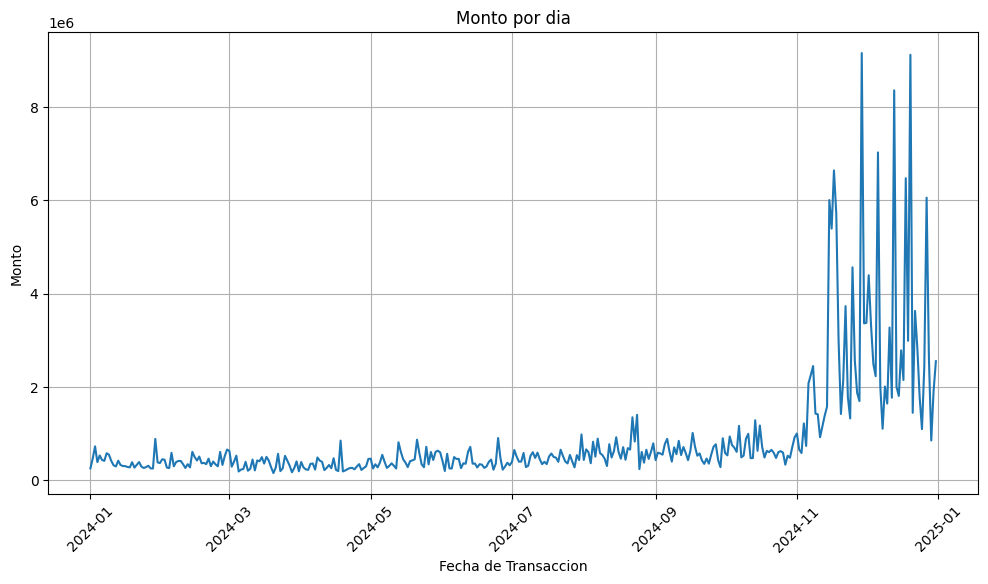

In [15]:
# Graficar la serie de tiempo agregada por día
plt.figure(figsize=(12, 6))
plt.plot(df_diario.index, df_diario['PAY_TOTAL_PAID_AMT'], linestyle='-')
plt.title('Monto por dia')
plt.xlabel('Fecha de Transaccion')
plt.ylabel('Monto')
plt.grid()
plt.xticks(rotation=45)
plt.show()

Se ve acelerado el monto en transacciones esto debido a la aceleracion natural de las fechas (Comenzando por Buen fin) 

In [16]:
print("Porcentaje de elemento mayores a 3 veces la mediana:",round(100*len(Archivo_Fraude[Archivo_Fraude['PAY_TOTAL_PAID_AMT']>=3*Archivo_Fraude['PAY_TOTAL_PAID_AMT'].median()])/len(Archivo_Fraude),1),"%")

Porcentaje de elemento mayores a 3 veces la mediana: 18.9 %


In [17]:
# AG es de analisis general
Archivo_Fraude_AG = Archivo_Fraude.copy()
Archivo_Fraude_AG = Archivo_Fraude_AG.drop(columns = ['CONTRAPARTE_HASH','TRX_ID_HASH','CUENTA_ID_HASH', 'NO_IDENTIFACION_HASH','PAY_CREATED_DATETIME','FECHA_INICIO_RELACION'])
Columnas_Objetos = Archivo_Fraude_AG.columns[Archivo_Fraude_AG.dtypes=='object']

In [18]:
# Numero de elementos unicos por categoría
Archivo_Fraude_AG[Columnas_Objetos].nunique()

ENTIDAD_FEDERATIVA             30
CALLE_HASH                    133
COLONIA_HASH                  131
CODIGO_POSTAL_HASH            130
KYC_PRIMARY_ACTIVITY_CODE      14
OCUPACION                       8
FLUJO                           2
MOVIMIENTO                     14
SERVICIO                       32
PAY_OPERATION_TYPE_ID           9
PAY_PAYMENT_METHOD_TYPE_ID      9
PAY_PAYMENT_METHOD_ID          21
dtype: int64

### 4- Dummies

In [19]:
Archivo_Fraude_AG_T_1 = pd.get_dummies(Archivo_Fraude_AG,columns=Columnas_Objetos,dummy_na=True,dtype=int)
Archivo_Fraude_AG_T_1

,EDAD,PAY_TOTAL_PAID_AMT,año_INICIO_RELACION,mes_INICIO_RELACION,dia_INICIO_RELACION,hora_INICIO_RELACION,minutos_INICIO_RELACION,segundos_INICIO_RELACION,dia_semana_INICIO_RELACION,semana_INICIO_RELACION,...,PAY_PAYMENT_METHOD_ID_oxxo,PAY_PAYMENT_METHOD_ID_paycash,PAY_PAYMENT_METHOD_ID_serfin,PAY_PAYMENT_METHOD_ID_sivale_despensa,PAY_PAYMENT_METHOD_ID_sivale_restaurant,PAY_PAYMENT_METHOD_ID_sodexo_despensa,PAY_PAYMENT_METHOD_ID_sodexo_restaurant,PAY_PAYMENT_METHOD_ID_toka,PAY_PAYMENT_METHOD_ID_visa,PAY_PAYMENT_METHOD_ID_nan
0,43.0,254.40,2022,6,9,16,4,59,3,23,...,0,0,0,0,0,0,0,0,0,0
1,60.0,68.00,2022,6,7,23,55,40,1,23,...,0,0,0,0,0,0,0,0,0,0
2,64.0,98.80,2023,3,24,14,59,59,4,12,...,0,0,0,0,0,0,0,0,0,0
3,33.0,31.64,2024,7,18,0,12,18,3,29,...,0,0,0,0,0,0,0,0,0,0
4,28.0,1300.00,2023,5,31,16,59,48,2,22,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177101,23.0,73.00,2022,6,21,22,5,52,1,25,...,0,0,0,0,0,0,0,0,0,0
177102,20.0,1700.50,2024,7,8,20,24,57,0,28,...,0,0,0,0,0,0,0,0,0,0
177103,37.0,1100.00,2022,6,9,21,14,52,3,23,...,0,0,0,0,0,0,0,0,0,0
177104,39.0,345.00,2022,12,6,16,10,9,1,49,...,0,0,0,0,0,0,0,0,0,0


In [20]:
Archivo_Fraude_AG.columns

Index(['ENTIDAD_FEDERATIVA', 'CALLE_HASH', 'COLONIA_HASH',
       'CODIGO_POSTAL_HASH', 'EDAD', 'KYC_PRIMARY_ACTIVITY_CODE', 'OCUPACION',
       'FLUJO', 'MOVIMIENTO', 'PAY_TOTAL_PAID_AMT', 'SERVICIO',
       'PAY_OPERATION_TYPE_ID', 'PAY_PAYMENT_METHOD_TYPE_ID',
       'PAY_PAYMENT_METHOD_ID', 'año_INICIO_RELACION', 'mes_INICIO_RELACION',
       'dia_INICIO_RELACION', 'hora_INICIO_RELACION',
       'minutos_INICIO_RELACION', 'segundos_INICIO_RELACION',
       'dia_semana_INICIO_RELACION', 'semana_INICIO_RELACION',
       'año_Transaccion', 'mes_Transaccion', 'dia_Transaccion',
       'hora_Transaccion', 'minutos_Transaccion', 'segundos_Transaccion',
       'dia_semana_Transaccion', 'semana_Transaccion'],
      dtype='object')

In [21]:
columnas_dummies = Archivo_Fraude_AG_T_1.columns[len(Archivo_Fraude_AG.columns)-len(Archivo_Fraude_AG_T_1.columns)-12:]

Nos deshacemos de los ultimos nulos

In [22]:
Columnas_nulas = Archivo_Fraude_AG_T_1.columns[Archivo_Fraude_AG_T_1.isnull().any()]
Archivo_Fraude_AG_T_1[Columnas_nulas].dtypes

EDAD                      float64
PAY_TOTAL_PAID_AMT        float64
año_Transaccion           float64
mes_Transaccion           float64
dia_Transaccion           float64
hora_Transaccion          float64
minutos_Transaccion       float64
segundos_Transaccion      float64
dia_semana_Transaccion    float64
semana_Transaccion         UInt32
dtype: object

In [23]:
# Rellenamos los datos faltantes con la mediana
for i in Columnas_nulas:
    Archivo_Fraude_AG_T_1[i] = Archivo_Fraude_AG_T_1[i].astype('float64')
    Mediana = Archivo_Fraude_AG_T_1[i].median()
    Archivo_Fraude_AG_T_1[i].fillna(Mediana, inplace=True)

### 4- Tratamiento de datos contínuos

In [24]:
round(Archivo_Fraude_AG_T_1[Columnas_Continuos].describe(),1)

,EDAD,PAY_TOTAL_PAID_AMT
count,177106.0,177106.0
mean,31.5,1811.6
std,9.9,30329.4
min,18.0,0.0
25%,24.0,125.0
50%,28.0,365.0
75%,37.0,855.0
max,66.0,6701785.0


In [25]:
Archivo_Fraude_AG_T_1[Columnas_Continuos].isnull().any()

EDAD                  False
PAY_TOTAL_PAID_AMT    False
dtype: bool

Rellenaremos la edad con la mediana. Sin embargo le pondremos un flag para los nulos
Para el monto como no sé que implicaciones tiene que esté vacio el dato o que signifique eso, pero como no estoy 100% seguro del contexto rellenaré con el promedio y le pondré una flag

In [26]:
Archivo_Fraude_AG_T_1['Edad_Nula'] = np.where(Archivo_Fraude_AG_T_1['EDAD'].isnull(),1,0)
Archivo_Fraude_AG_T_1['Monto_NULO'] = np.where(Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT'].isnull(),1,0)

In [27]:
Archivo_Fraude_AG_T_1['EDAD'] = np.where(Archivo_Fraude_AG_T_1['EDAD'].isnull(),Archivo_Fraude_AG_T_1['EDAD'].median(),Archivo_Fraude_AG_T_1['EDAD'])
Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT'] = np.where(Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT'].isnull(),Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT'].mean(),Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT'])

In [28]:
# Comprobamos que ya no hay nulos
Archivo_Fraude_AG_T_1[Columnas_Continuos].isnull().any()

EDAD                  False
PAY_TOTAL_PAID_AMT    False
dtype: bool

In [29]:
round(Archivo_Fraude_AG_T_1[Columnas_Continuos].describe(),1)

,EDAD,PAY_TOTAL_PAID_AMT
count,177106.0,177106.0
mean,31.5,1811.6
std,9.9,30329.4
min,18.0,0.0
25%,24.0,125.0
50%,28.0,365.0
75%,37.0,855.0
max,66.0,6701785.0


In [30]:
np.log1p(Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT']).describe().round(1)

count    177106.0
mean          5.7
std           1.9
min           0.0
25%           4.8
50%           5.9
75%           6.8
max          15.7
Name: PAY_TOTAL_PAID_AMT, dtype: float64

In [31]:
Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT'] = np.log1p(Archivo_Fraude_AG_T_1['PAY_TOTAL_PAID_AMT'])

Aquí notamos que el ultimo cuantil dista bastante de aquel al 75% por eso estandarizaremos

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Archivo_Fraude_AG_T_1)

### 6- Aplicamos PCA

In [33]:
Componentes = 3
pca = PCA(n_components=Componentes) 

Archivo_Fraude_T_2 = pca.fit_transform(X_scaled)
lista_componente = []
for i in range(1,Componentes+1):
    lista_componente.append(f'Componente_{i}')
# 3. Crear un DataFrame con los resultados de PCA
pca_df = pd.DataFrame(data=Archivo_Fraude_T_2, columns=lista_componente)

In [34]:
pca_df.describe().round(1)

,Componente_1,Componente_2,Componente_3
count,177106.0,177106.0,177106.0
mean,-0.0,0.0,-0.0
std,3.4,3.0,2.9
min,-6.6,-6.1,-5.9
25%,-2.6,-2.3,-2.1
50%,0.8,-0.3,-0.2
75%,3.2,2.8,1.5
max,4.8,6.5,6.2


### 7-Modelado

In [35]:
# Tomamos el 1% de los datos como el mínimo para generar un cluster
dbscan = DBSCAN(eps=1, min_samples=math.ceil(len(pca_df)/100))  
dbscan_labels = dbscan.fit_predict(pca_df)

In [36]:
pca_df['DBSCAN_Label'] = dbscan_labels
pca_df['DBSCAN_Label'].value_counts()

DBSCAN_Label
 7    61343
 1    24266
 4    19711
 5    16416
-1    13982
 0    13868
 3    10900
 2     7115
 6     5940
 8     3565
Name: count, dtype: int64

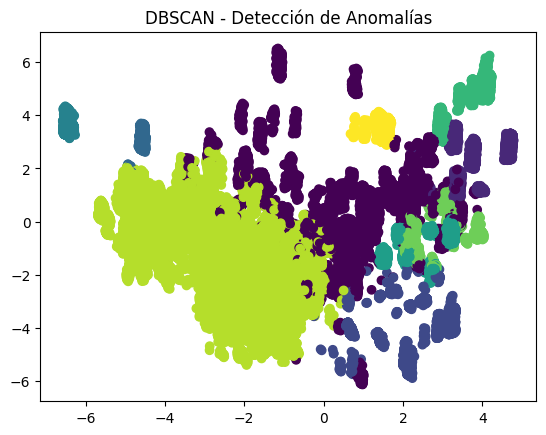

In [37]:
import matplotlib.pyplot as plt
plt.scatter(pca_df['Componente_1'],pca_df['Componente_2'], c=dbscan_labels, cmap='viridis', marker='o')
plt.title('DBSCAN - Detección de Anomalías')
plt.show()

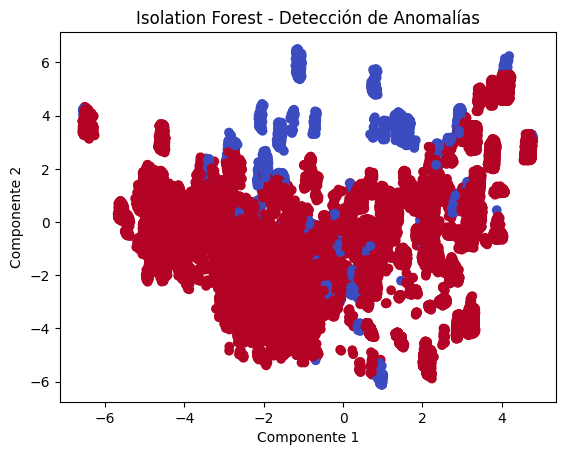

In [38]:
from sklearn.ensemble import IsolationForest

# 1. Aplicar Isolation Forest
iso_forest = IsolationForest(contamination=0.05,random_state= 0)
iso_labels = iso_forest.fit_predict(pca_df)

# 2. Añadir etiquetas al DataFrame
pca_df['Isolation_Forest_Label'] = iso_labels

plt.scatter(pca_df['Componente_1'], pca_df['Componente_2'], c=iso_labels, cmap='coolwarm', marker='o')
plt.title('Isolation Forest - Detección de Anomalías')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

In [39]:
Archivo_Fraude_AG_T_1['DB_SCAN_Label'] = dbscan_labels
# Pasamos a Dummies las etiquetas de DB_SCAN
Archivo_Fraude_AG_T_2 =  pd.get_dummies(Archivo_Fraude_AG_T_1,columns=['DB_SCAN_Label'],dummy_na=True,dtype=int)

### 8- Correlaciones y otros:

In [40]:
from sklearn.ensemble import RandomForestClassifier
clf_rnd = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf_rnd.fit(Archivo_Fraude_AG_T_2, iso_labels)
# Podemos extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(Archivo_Fraude_AG_T_2), clf_rnd.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(15)

DB_SCAN_Label_8.0                                                  0.098781
MOVIMIENTO_Ingreso por procesamiento de pagos                      0.058073
DB_SCAN_Label_5.0                                                  0.053095
CALLE_HASH_Jn74BcjMYh/87BOiJ7Jt0k8GSSdIjSnk04d0hSwRKzc=            0.046363
DB_SCAN_Label_-1.0                                                 0.042695
FLUJO_ENTRADAS                                                     0.031860
KYC_PRIMARY_ACTIVITY_CODE_AC016002                                 0.027628
FLUJO_SALIDAS                                                      0.024299
SERVICIO_PAGO_AGREGADOR                                            0.024023
CODIGO_POSTAL_HASH_c1PfIqqBdt8YTh49ZCTKUIi+m1pot5HYxvjmhta2PSY=    0.023932
MOVIMIENTO_Money in vía P2P                                        0.019985
ENTIDAD_FEDERATIVA_Campeche                                        0.019327
PAY_PAYMENT_METHOD_ID_account_money                                0.019077
PAY_TOTAL_PA

In [41]:
Archivo_Fraude_AG_T_2['Isolation_Forest_Label'] = iso_labels

In [42]:
# Calculamos la correlación positiva (Que variables hacen que sea mas probable que seleccionen hotel)
corrs = Archivo_Fraude_AG_T_2.apply(lambda col: col.corr(Archivo_Fraude_AG_T_2['Isolation_Forest_Label']))

# Ordenamos las correlaciones de mayor a menor
corrs = corrs.sort_values(ascending=False)

# Obtenemos el top 10 de correlaciones
top_10 = corrs.head(15)

# Mostramos los resultados
print(round(100*top_10,1))

c:\Users\jesus\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jesus\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Isolation_Forest_Label                           100.0
KYC_PRIMARY_ACTIVITY_CODE_nan                     28.4
dia_semana_INICIO_RELACION                        18.9
MOVIMIENTO_Ingreso por procesamiento de pagos     18.8
año_INICIO_RELACION                               18.4
hora_INICIO_RELACION                              17.9
DB_SCAN_Label_7.0                                 16.7
FLUJO_ENTRADAS                                    16.5
EDAD                                              11.3
PAY_PAYMENT_METHOD_TYPE_ID_debit_card             10.3
SERVICIO_POINT                                    10.3
PAY_OPERATION_TYPE_ID_pos_payment                 10.3
OCUPACION_EMPLOYEE                                 9.6
DB_SCAN_Label_1.0                                  9.1
ENTIDAD_FEDERATIVA_Estado De México                9.0
dtype: float64


In [43]:
# Calculamos la correlación positiva (Que variables hacen que sea mas probable que seleccionen hotel)
corrs = Archivo_Fraude_AG_T_2.apply(lambda col: col.corr(Archivo_Fraude_AG_T_2['Isolation_Forest_Label']))

# Ordenamos las correlaciones de mayor a menor y quitamos los numeros que se van
corrs = corrs.sort_values(ascending=False)[corrs.sort_values(ascending=False).notnull()]

# Obtenemos el top 10 de correlaciones
top_10 = corrs.tail(15)

# Mostramos los resultados
print(round(100*top_10,1))

c:\Users\jesus\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jesus\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


PAY_PAYMENT_METHOD_TYPE_ID_digital_currency                       -15.1
PAY_PAYMENT_METHOD_ID_consumer_credits                            -15.1
SERVICIO_PAGO_CONSUMER_CREDITS                                    -15.2
segundos_INICIO_RELACION                                          -15.2
FLUJO_SALIDAS                                                     -16.5
SERVICIO_PAGO_TARJETA_MP                                          -16.6
MOVIMIENTO_Pagos                                                  -22.2
OCUPACION_nan                                                     -28.8
DB_SCAN_Label_-1.0                                                -30.9
ENTIDAD_FEDERATIVA_Campeche                                       -38.6
COLONIA_HASH_Hp661ndQuppX5PH/LUrINbJCMhvy/U9B/j8d6BvXbYA=         -39.5
CODIGO_POSTAL_HASH_c1PfIqqBdt8YTh49ZCTKUIi+m1pot5HYxvjmhta2PSY=   -39.5
KYC_PRIMARY_ACTIVITY_CODE_AC016002                                -39.5
CALLE_HASH_Jn74BcjMYh/87BOiJ7Jt0k8GSSdIjSnk04d0hSwRKzc=         

In [44]:
# Le pegamos nuevamente las etiquetas de id y otros
Archivo_Fraude_AG_T_3 = Archivo_Fraude_AG_T_2.copy()
Archivo_Fraude_AG_T_3['CUENTA_ID_HASH'] =Archivo_Fraude['CUENTA_ID_HASH']
Archivo_Fraude_AG_T_3['CONTRAPARTE_HASH'] =Archivo_Fraude['CONTRAPARTE_HASH']
Archivo_Fraude_AG_T_3['TRX_ID_HASH'] =Archivo_Fraude['TRX_ID_HASH']
Archivo_Fraude_AG_T_3['NO_IDENTIFACION_HASH'] =Archivo_Fraude['NO_IDENTIFACION_HASH']
Archivo_Fraude_AG_T_3['PAY_TOTAL_PAID_AMT'] =Archivo_Fraude['PAY_TOTAL_PAID_AMT']
Archivo_Fraude_AG_T_3['KYC_PRIMARY_ACTIVITY_CODE'] = Archivo_Fraude['KYC_PRIMARY_ACTIVITY_CODE']
Archivo_Fraude_AG_T_3['OCUPACION'] = Archivo_Fraude['OCUPACION']
Archivo_Fraude_AG_T_3['ENTIDAD_FEDERATIVA'] = Archivo_Fraude['ENTIDAD_FEDERATIVA']
Archivo_Fraude_AG_T_3['CODIGO_POSTAL_HASH'] = Archivo_Fraude['CODIGO_POSTAL_HASH']
Archivo_Fraude_AG_T_3['SERVICIO'] = Archivo_Fraude['SERVICIO']
Archivo_Fraude_AG_T_3['PAY_PAYMENT_METHOD_ID'] =  Archivo_Fraude['PAY_PAYMENT_METHOD_ID']

### 9- Analisis agrupado por Cuenta: 

In [45]:
Tabla_dinamica_dummies = pd.pivot_table(Archivo_Fraude_AG_T_3,values=columnas_dummies,index='CUENTA_ID_HASH',aggfunc= 'sum',dropna=False)

In [46]:
Tabla_dinamica_transferencias_tot =  pd.pivot_table(Archivo_Fraude_AG_T_3,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'sum',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Total_Monto'})
Tabla_dinamica_transferencias_mean =  pd.pivot_table(Archivo_Fraude_AG_T_3,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'mean',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Media_Monto'})
Tabla_dinamica_transferencias_Rec =  pd.pivot_table(Archivo_Fraude_AG_T_3,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'count',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Rec_Trans'})
Tabla_dinamica_transferencias_max =  pd.pivot_table(Archivo_Fraude_AG_T_3,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'max',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Max_Monto'})
Tabla_dinamica_transferencias_min =  pd.pivot_table(Archivo_Fraude_AG_T_3,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'min',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Min_Monto'})

In [47]:
Archivo_Fraude_AG_T_3['Isolation_Forest_Label'] = np.where(Archivo_Fraude_AG_T_3['Isolation_Forest_Label']==-1,1,0)
Tabla_dinamica_edad =  pd.pivot_table(Archivo_Fraude_AG_T_3,values='EDAD',index='CUENTA_ID_HASH',aggfunc= 'mean',dropna=False)
Tabla_dinamica_IS_REC=  pd.pivot_table(Archivo_Fraude_AG_T_3,values='Isolation_Forest_Label',index='CUENTA_ID_HASH',aggfunc= 'count',dropna=False).rename(columns={'Isolation_Forest_Label':'Rec_ISF'})
Tabla_dinamica_IS_SUM=  pd.pivot_table(Archivo_Fraude_AG_T_3,values='Isolation_Forest_Label',index='CUENTA_ID_HASH',aggfunc= 'sum',dropna=False).rename(columns={'Isolation_Forest_Label':'Tot_ISF'})

Con mas tiempo hubiera agregado (minimo, maximo, mediana) de transacciones por dia,por mes, por semana, por año, etc 
periodo entre una transaccion y otra, etc.

In [48]:
Lista_DF = [Tabla_dinamica_transferencias_mean,Tabla_dinamica_transferencias_Rec,Tabla_dinamica_transferencias_max,Tabla_dinamica_transferencias_min,
Tabla_dinamica_edad,Tabla_dinamica_IS_SUM,Tabla_dinamica_dummies]

df_Agrupado = Tabla_dinamica_transferencias_tot

for i in range(0,len(Lista_DF)):
    df_Agrupado = pd.merge(df_Agrupado, Lista_DF[i], on='CUENTA_ID_HASH', how='left')

In [49]:
df_Agrupado['Indicador_Isolation_F'] = round(100*df_Agrupado['Tot_ISF']/df_Agrupado['Rec_Trans'],1)

In [50]:
df_Agrupado.sort_values(by='Indicador_Isolation_F',ascending=False,inplace=True)

In [51]:
Cuentas_anomalas = df_Agrupado[df_Agrupado['Indicador_Isolation_F']>=10]
Cuentas_no_anomalas = df_Agrupado[df_Agrupado['Indicador_Isolation_F']<10]
len(Cuentas_no_anomalas)+len(Cuentas_anomalas)  == len(df_Agrupado)
# Esto da false ya que hay una cuenta sin transacciones. Por facilidad esta vez la ignoraremos y partiremos en los individuos cuyas transacciones mas del 10% sean anomalas
# El 10% se eligió porque no necesariamente aunque tengas una transaccion anomala significa que estas involucrado en fraude

False

In [52]:
len(Cuentas_anomalas)

6

### 9.5 Analizaremos las estadisticas basicas de ambas poblaciones

In [53]:
Cuentas_anomalas[Cuentas_anomalas.columns[:6]].describe().round(0)

,Total_Monto,Media_Monto,Rec_Trans,Max_Monto,Min_Monto,EDAD
count,6.0,6.0,6.0,6.0,6.0,6.0
mean,5519556.0,1277.0,4322.0,74622.0,5.0,31.0
std,10189585.0,968.0,8281.0,87430.0,9.0,8.0
min,300345.0,320.0,307.0,12000.0,0.0,24.0
25%,462591.0,831.0,940.0,16125.0,0.0,26.0
50%,895403.0,1104.0,1004.0,35750.0,0.0,29.0
75%,3712816.0,1225.0,1368.0,99025.0,4.0,32.0
max,26055913.0,3129.0,21209.0,234534.0,23.0,46.0


In [54]:
Cuentas_no_anomalas[Cuentas_no_anomalas.columns[:6]].describe().round(0)

,Total_Monto,Media_Monto,Rec_Trans,Max_Monto,Min_Monto,EDAD
count,133.0,133.0,133.0,133.0,133.0,133.0
mean,2163422.0,4138.0,1137.0,133763.0,13.0,34.0
std,6891242.0,10210.0,2674.0,618772.0,54.0,11.0
min,22316.0,121.0,7.0,4238.0,0.0,18.0
25%,200804.0,658.0,174.0,12000.0,0.0,25.0
50%,506906.0,1070.0,386.0,20800.0,0.0,30.0
75%,1513958.0,3574.0,1109.0,50000.0,0.0,39.0
max,73000046.0,94291.0,21970.0,6701785.0,305.0,66.0


In [55]:
(100*(Cuentas_anomalas[Cuentas_anomalas.columns[:6]].describe()- Cuentas_no_anomalas[Cuentas_no_anomalas.columns[:6]].describe())/Cuentas_no_anomalas[Cuentas_no_anomalas.columns[:6]].describe()).round(0)

,Total_Monto,Media_Monto,Rec_Trans,Max_Monto,Min_Monto,EDAD
count,-95.0,-95.0,-95.0,-95.0,-95.0,-95.0
mean,155.0,-69.0,280.0,-44.0,-64.0,-7.0
std,48.0,-91.0,210.0,-86.0,-83.0,-29.0
min,1246.0,165.0,4286.0,183.0,0.0,33.0
25%,130.0,26.0,440.0,34.0,0.0,6.0
50%,77.0,3.0,160.0,72.0,50.0,-3.0
75%,145.0,-66.0,23.0,98.0,3314.0,-17.0
max,-64.0,-97.0,-3.0,-97.0,-92.0,-30.0


El modelo concluye:
* El total  de los montos es 155% mas alta.
* El total de transacciones que realizan es 280% mas alto
* Suelen transferir montos pequeños, pero en mayor cantidad para hacer mas dificil de detectar su  actividad anomala

<Axes: >

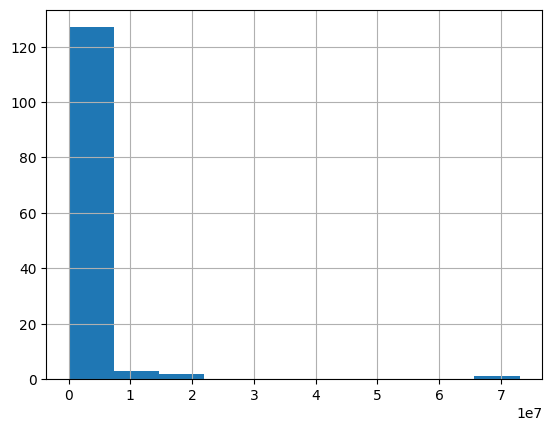

In [56]:
Cuentas_no_anomalas['Total_Monto'].hist()

<Axes: >

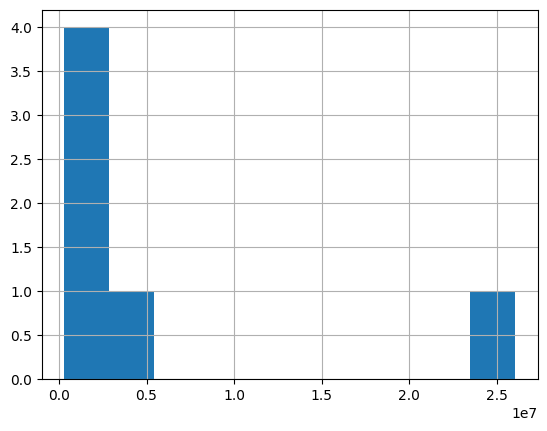

In [57]:
Cuentas_anomalas['Total_Monto'].hist()

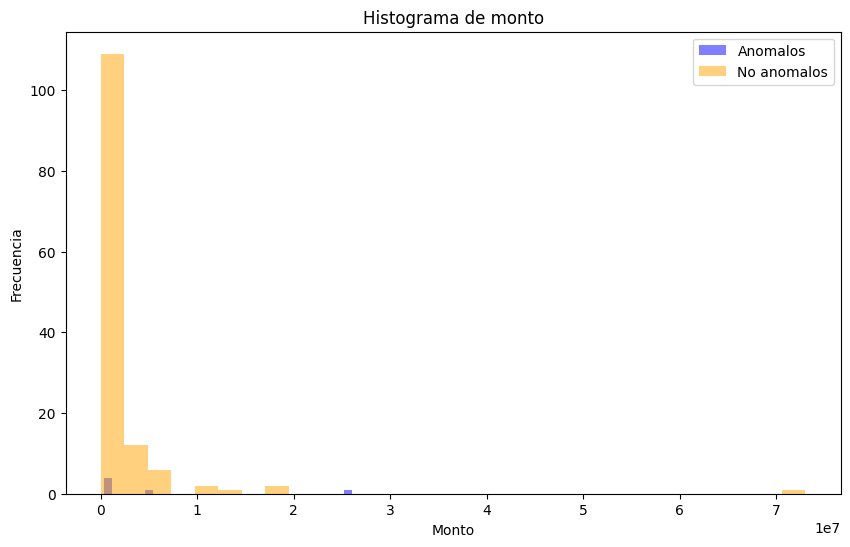

In [58]:
# Crear la figura y los ejes
plt.figure(figsize=(10, 6))

# Graficar los histogramas
plt.hist(Cuentas_anomalas['Total_Monto'], bins=30, alpha=0.5, label='Anomalos', color='blue')
plt.hist(Cuentas_no_anomalas['Total_Monto'], bins=30, alpha=0.5, label='No anomalos', color='orange')

# Establecer límites para los ejes X e Y
# plt.xlim(0,7)  # Limites para el eje X
# plt.ylim(0, 120)  # Limites para el eje Y

# Etiquetas y título
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.title('Histograma de monto')
plt.legend()

# Mostrar la gráfica
plt.show()

### 9.6 Analisis de las columnas mas importantes

Top  caracteristicas:
* PAY_TOTAL_PAID_AMT
* semana_Transaccion
* mes_Transaccion
* hora_Transaccion
* KYC_PRIMARY_ACTIVITY_CODE
* OCUPACION
* ENTIDAD_FEDERATIVA
* CODIGO_POSTAL
* SERVICIO
* PAY_PAYMENT_METHOD_ID

In [59]:
Lista_anomala = list(Cuentas_anomalas.index)
Archivo_Fraude_AG_T_3['Flag_Ctas_Anomalas'] = Archivo_Fraude_AG_T_3['CUENTA_ID_HASH'].isin(Lista_anomala).astype(int)
Transacciones_Cuentas_Anomalas = Archivo_Fraude_AG_T_3[Archivo_Fraude_AG_T_3['Flag_Ctas_Anomalas']==1]
Transacciones_Cuentas_no_Anomalas = Archivo_Fraude_AG_T_3[Archivo_Fraude_AG_T_3['Flag_Ctas_Anomalas']==0]

In [60]:
Transacciones_Cuentas_Anomalas['PAY_PAYMENT_METHOD_ID'].value_counts()

PAY_PAYMENT_METHOD_ID
account_money        6474
debvisa              5511
visa                 3464
master               3437
debmaster            2130
consumer_credits     1314
oxxo                 1078
clabe                 990
amex                  203
paycash               149
bancomer               80
bank                   31
banamex                21
sivale_despensa         6
toka                    6
bank_express            3
edenred                 3
serfin                  1
sodexo_restaurant       1
Name: count, dtype: int64

In [61]:
Transacciones_Cuentas_no_Anomalas['PAY_PAYMENT_METHOD_ID'].value_counts()

PAY_PAYMENT_METHOD_ID
account_money        51089
debvisa              20901
clabe                18471
visa                  9044
debmaster             8981
master                8140
consumer_credits      3207
oxxo                  1118
paycash                999
sivale_despensa        868
sodexo_despensa        845
amex                   713
edenred                241
toka                    93
bancomer                45
sivale_restaurant       29
sodexo_restaurant        9
banamex                  9
bank                     9
bank_express             2
Name: count, dtype: int64

<Axes: >

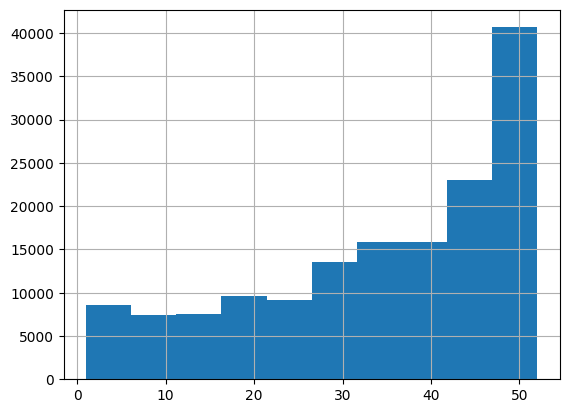

In [62]:
Transacciones_Cuentas_no_Anomalas['semana_Transaccion'].hist()

<Axes: >

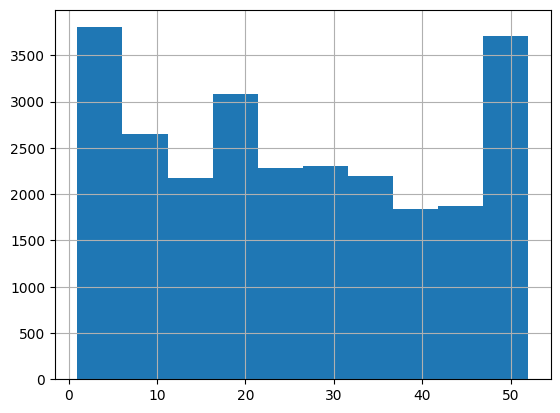

In [63]:
Transacciones_Cuentas_Anomalas['semana_Transaccion'].hist()

<Axes: >

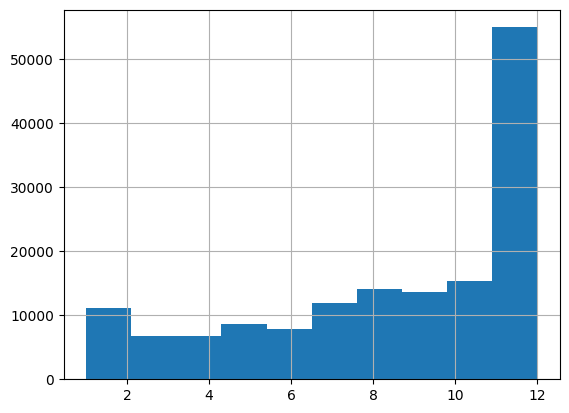

In [64]:
Transacciones_Cuentas_no_Anomalas['mes_Transaccion'].hist()

<Axes: >

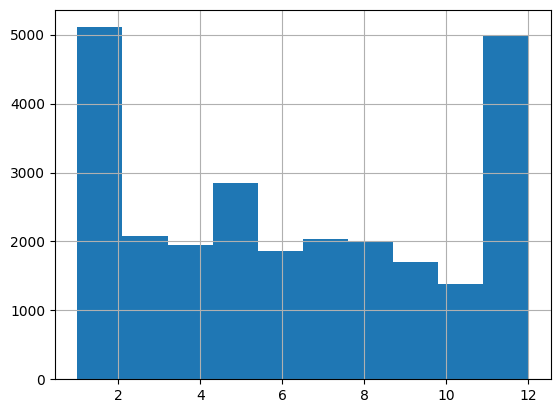

In [65]:
Transacciones_Cuentas_Anomalas['mes_Transaccion'].hist()

In [66]:
Transacciones_Cuentas_Anomalas['mes_Transaccion'].value_counts()

mes_Transaccion
12.0    3028
5.0     2849
1.0     2629
2.0     2478
3.0     2076
7.0     2028
8.0     1985
11.0    1957
4.0     1943
6.0     1865
9.0     1708
10.0    1387
Name: count, dtype: int64

<Axes: >

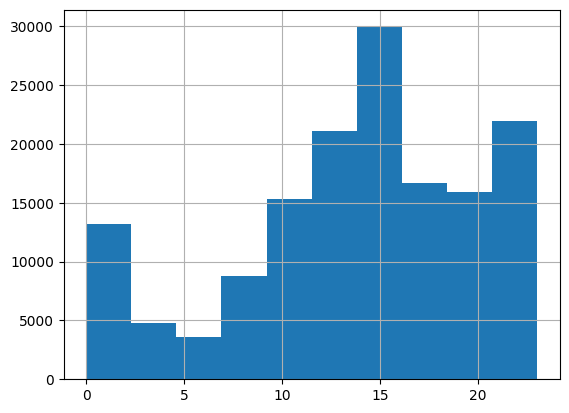

In [67]:
Transacciones_Cuentas_no_Anomalas['hora_Transaccion'].hist()

<Axes: >

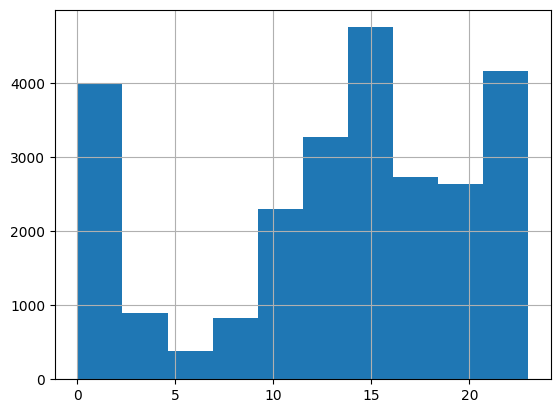

In [68]:
Transacciones_Cuentas_Anomalas['hora_Transaccion'].hist()

In [69]:
Transacciones_Cuentas_no_Anomalas['KYC_PRIMARY_ACTIVITY_CODE'].value_counts(dropna=False)/Transacciones_Cuentas_no_Anomalas['KYC_PRIMARY_ACTIVITY_CODE'].value_counts(dropna=False).sum()

KYC_PRIMARY_ACTIVITY_CODE
NaN         0.800778
AC022001    0.060103
AC003014    0.049572
AC010001    0.030072
AC023016    0.012158
561990      0.012125
AC010002    0.011642
AC024002    0.008322
AC025005    0.005848
AC027001    0.005239
AC013001    0.004141
Name: count, dtype: float64

In [70]:
Transacciones_Cuentas_Anomalas['KYC_PRIMARY_ACTIVITY_CODE'].value_counts(dropna=False)/Transacciones_Cuentas_Anomalas['KYC_PRIMARY_ACTIVITY_CODE'].value_counts(dropna=False).sum()

KYC_PRIMARY_ACTIVITY_CODE
AC016002    0.817838
AC019004    0.056646
NaN         0.048085
AC012002    0.041144
AC020002    0.036286
Name: count, dtype: float64

In [71]:
Transacciones_Cuentas_no_Anomalas['OCUPACION'].value_counts()

OCUPACION
EMPLOYEE                    27219
SELFEMPLOYEDPROFESSIONAL    26927
STUDENT                     21859
PARTNEROROWNER              15771
HOUSEKEEPER                 13490
FREELANCER                  12039
MERCHANT                     2309
OWNBUSINESS                  2177
Name: count, dtype: int64

In [72]:
Transacciones_Cuentas_Anomalas['OCUPACION'].value_counts(dropna=False)/Transacciones_Cuentas_Anomalas['OCUPACION'].value_counts(dropna=False).sum()

OCUPACION
NaN               0.951915
STUDENT           0.036247
PARTNEROROWNER    0.011838
Name: count, dtype: float64

In [73]:
Transacciones_Cuentas_no_Anomalas['ENTIDAD_FEDERATIVA'].value_counts()

ENTIDAD_FEDERATIVA
Estado De México       34720
Querétaro              23271
Distrito Federal       15642
Durango                11783
Jalisco                 7376
Tamaulipas              6324
Sonora                  5672
Veracruz                5366
Yucatán                 5219
Nuevo León              5036
Coahuila                3900
Puebla                  3230
Michoacán               3120
Quintana Roo            2383
Aguascalientes          2241
Hidalgo                 2107
Chiapas                 2024
Guerrero                1774
Oaxaca                  1623
Baja California Sur     1516
Tabasco                 1282
Guanajuato              1151
Tlaxcala                1129
Morelos                 1066
Campeche                 822
San Luis Potosí          513
Nayarit                  473
Chihuahua                236
Colima                   123
Sinaloa                   51
Name: count, dtype: int64

In [74]:
Transacciones_Cuentas_Anomalas['ENTIDAD_FEDERATIVA'].value_counts()

ENTIDAD_FEDERATIVA
Campeche     21209
Veracruz      1469
Morelos       1067
Michoacán      941
Jalisco        940
Guerrero       307
Name: count, dtype: int64

In [75]:
Transacciones_Cuentas_Anomalas['CODIGO_POSTAL_HASH'].value_counts()

CODIGO_POSTAL_HASH
c1PfIqqBdt8YTh49ZCTKUIi+m1pot5HYxvjmhta2PSY=    21209
JCv0iHSC0bn3HPMo15ePEDqcAxyoA7S/V/K2azboJEE=     1469
lE5DSWE1A1ReF0uJ0K0/GnZgS5RRmubQBaMi+ghtyk0=     1067
QS97T6Nmu1ghyBmSS24sDk9S/z/JGcO4lK7+WNlRZ1g=      941
UqWzGb9UHIqvAD/+1PRWGtBIPpyspEvu572g5ZuNndE=      940
COoHeZ2puJSPHfLjOd7z23r4TpKsKqWajannleuXhY0=      307
Name: count, dtype: int64

In [76]:
Transacciones_Cuentas_no_Anomalas['SERVICIO'].value_counts()

SERVICIO
POINT                                 35689
PAYOUT_TRANSFER                       26352
PAGO_DINERO_CUENTA                    24252
FONDEO_CLABE                          18338
TRANSFERENCIA_DINERO_CUENTA           15574
PAGO_AGREGADOR                        13539
PAGO_TARJETA_MP                        9089
PAGO_CONSUMER_CREDITS                  3192
PAGO_COMISIONISTA                      1160
FONDEO_COMISIONISTAS                    953
DISPOSICION_TARJETA_MP                  478
COMPRA_CRYPTO                           358
VENTA_CRYPTO                            352
REMESAS_XOOM                            329
FONDEO_T_CREDITO                        316
FONDEO_T_DEBITO                         180
REMESAS_TRANSNETWORK_WILL_CALL          168
PAGO_DOMICILIADO_CON_DINERO_CUENTA      161
TRANSFERENCIA_T_CREDITO                 123
MERCHANT_CREDIT                          96
REMESAS_WU_F1                            94
REMESAS_FELIX_PAGO                       91
REMESAS_TRANSNETWORK_DI

In [77]:
Transacciones_Cuentas_Anomalas['SERVICIO'].value_counts()

SERVICIO
PAGO_AGREGADOR                        14159
PAGO_DINERO_CUENTA                     2969
PAGO_TARJETA_MP                        2377
PAGO_CONSUMER_CREDITS                  1314
PAGO_COMISIONISTA                      1220
TRANSFERENCIA_DINERO_CUENTA            1051
PAYOUT_TRANSFER                        1031
FONDEO_CLABE                            987
POINT                                   701
DISPOSICION_TARJETA_MP                   38
RETIRO_MISMA_TITULARIDAD                 34
PAGO_DOMICILIADO_CON_DINERO_CUENTA       33
FONDEO_COMISIONISTAS                      7
PAGO_CLABE                                3
FONDEO_T_CREDITO                          3
COMPRA_CRYPTO                             3
MERCHANT_CREDIT                           3
Name: count, dtype: int64

In [78]:
Transacciones_Cuentas_Anomalas['PAY_TOTAL_PAID_AMT'].sum()

33117338.92

In [79]:
len(Transacciones_Cuentas_Anomalas)/(len(Transacciones_Cuentas_Anomalas)+len(Transacciones_Cuentas_no_Anomalas))

0.1464264338870507

In [80]:
Transacciones_Cuentas_Anomalas['mes_INICIO_RELACION'].value_counts()/Transacciones_Cuentas_Anomalas['mes_INICIO_RELACION'].value_counts().sum()

mes_INICIO_RELACION
6     0.895230
1     0.056646
12    0.036286
3     0.011838
Name: count, dtype: float64

In [81]:
Transacciones_Cuentas_no_Anomalas['mes_INICIO_RELACION'].value_counts()/Transacciones_Cuentas_no_Anomalas['mes_INICIO_RELACION'].value_counts().sum()

mes_INICIO_RELACION
6     0.284343
5     0.159195
7     0.156165
12    0.092563
10    0.091901
8     0.072817
1     0.071018
3     0.032969
4     0.012324
9     0.012231
11    0.012013
2     0.002461
Name: count, dtype: float64

### 10- Conclusiones

El modelo ha revelado las siguientes conclusiones clave:
* Total acumulado por anomalías: $33,117,339.
* Monto Total: 155% mas en cuentas anomalas.
* 6 cuentas generan el 14% de las transferencias.
* Numero de transacciones: 280% mas transacciones.
* 6 cuentas generan el 14% de las transferencias.
* Patrones de transferencia: Se identifica una tendencia a realizar transferencias de montos pequeños en grandes volúmenes, lo que dificulta la detección de actividades anómalas.
* Priemras dos semans del año: Las dos primeras semanas del año mostraron un incremento en la detección de anomalías, lo cual merece atención especial.
* Importancia del KYC: 80% de las transferencias no anomalas generaron código KYC.
* Horas críticas: Las primeras horas de la madrugada (desde la medianoche) emergen como un período crítico para la detección de anomalías.
* Situación en Campeche: El estado de Campeche se destaca como un área crítica para el establecimiento y monitoreo de anomalías.
* Impacto del servicio de pago agregador: Este servicio actúa como un factor determinante para la identificación de actividades anómalas.
* Influencia del trabajo como "partowner": La modalidad laboral "partowner" también parece ser un indicador relevante en la detección de anomalías.
* El total acumulado por 6 cuentas anomalas es de $33,117,338.92 en un año de transacciones.
* 95% de la ocupacion de las transferencias de es nan
* Cuentas anomalas: "nrBNafOvnLhHNZvd8u6UCUXGd4peAXQhmOh0M9L/4Jk=", "kukGAp3QLhZty0U+7xJ4jetLi+Jjb8GCZFxTed+jFHU="
"hvakB1XSKyggQkhUpMehZCLubaf+U3GfSMXo5zc40ag=","JVnknMJb26IQL/xn+y62yYSFG4aQWx/54zHR+IUrceI=", "Wel67AJb0zIK3gDHK9pK43UzXsOW4639fGrZa0l5Tg0=", "ZfbwRPEmQlm2haNV7ooD7htGISRV+JTZVvKbNiunSvQ="

In [82]:
Cuentas_anomalas

,Total_Monto,Media_Monto,Rec_Trans,Max_Monto,Min_Monto,EDAD,Tot_ISF,CALLE_HASH_+IKAbxZSwhuJQ6xsCDIxjaeiNFZrfeqisb9+ddlez1c=,CALLE_HASH_/2SAQRwRRWcQOErQdv4b7fs7VnZkWtQpUt3xKG6u9qU=,CALLE_HASH_/60HBcrmYH1NeLU4GND3+FJBqDMpG3xzHId+9NwcMwE=,...,SERVICIO_REMESAS_WU_F2,SERVICIO_REMESAS_XOOM,SERVICIO_RETIRO_MISMA_TITULARIDAD,SERVICIO_TRANSFERENCIA_CONSUMER_CREDITS,SERVICIO_TRANSFERENCIA_DINERO_CUENTA,SERVICIO_TRANSFERENCIA_T_CREDITO,SERVICIO_TRANSFERENCIA_T_DEBITO,SERVICIO_VENTA_CRYPTO,SERVICIO_nan,Indicador_Isolation_F
CUENTA_ID_HASH,,,,,,,,,,,,,,,,,,,,,
nrBNafOvnLhHNZvd8u6UCUXGd4peAXQhmOh0M9L/4Jk=,1059882.41,993.329344,1067,55000.00,0.01,46.0,388,0,0,0,...,0,0,0,0,482,0,0,0,0,36.4
kukGAp3QLhZty0U+7xJ4jetLi+Jjb8GCZFxTed+jFHU=,730924.24,776.752646,941,12000.00,0.01,30.0,327,0,0,0,...,0,0,0,0,287,0,0,0,0,34.8
hvakB1XSKyggQkhUpMehZCLubaf+U3GfSMXo5zc40ag=,26055913.06,1228.530957,21209,113700.00,5.00,24.0,6005,0,0,0,...,0,0,0,0,26,0,0,0,0,28.3
JVnknMJb26IQL/xn+y62yYSFG4aQWx/54zHR+IUrceI=,300345.01,319.515968,940,16500.00,0.01,26.0,249,0,0,0,...,0,0,0,0,239,0,0,0,0,26.5
Wel67AJb0zIK3gDHK9pK43UzXsOW4639fGrZa0l5Tg0=,373146.39,1215.460554,307,16000.00,0.02,33.0,72,0,0,0,...,0,0,0,0,17,0,0,0,0,23.5
ZfbwRPEmQlm2haNV7ooD7htGISRV+JTZVvKbNiunSvQ=,4597127.81,3129.426692,1469,234533.67,23.00,28.0,225,0,0,0,...,0,0,34,0,0,0,0,0,0,15.3
